# Compare Chunking Outputs Notebook

In [26]:
#Imports
from __future__ import annotations
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = Path('/Users/matthewplambeck/Desktop/Deployable-Knowledge/outputs-test')

FILES = {'semantic_ts': BASE_DIR / 'chunker-semantic.json', 
         'python_legacy':  BASE_DIR / 'chunker-python.json'}


def load_chunks(path: Path, source_name: str) -> pd.DataFrame:
    payload = json.loads(path.read_text())
    rows = payload['chunks'] if isinstance(payload, dict) and 'chunks' in payload else payload
    frame = pd.DataFrame(rows).copy()
    frame['source_name'] = source_name
    frame['model'] = payload.get('model', source_name) if isinstance(payload, dict) else source_name
    frame['wordCount'] = frame['content'].str.split().str.len()
    frame['sentenceCountApprox'] = (
        frame['content']
        .str.replace('', ' ', regex=False)
        .str.split('.')
        .apply(lambda parts: sum(1 for part in parts if part.strip())))
    return frame[['source_name', 'model', 'pageIndex', 'chunkIndex', 'chunkId', 'wordCount', 'sentenceCountApprox', 'content']]


def load_available_frames() -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    frames: dict[str, pd.DataFrame] = {}
    status_rows: list[dict[str, str]] = []

    for name, path in FILES.items():
        required = name 
        exists = path.exists()
        status_rows.append({
            'source_name': name,
            'path': str(path),
            'required': 'yes' if required else 'no',
            'exists': 'yes' if exists else 'no',
        })

        if exists:
            load_name = 'baseline_ts' if name == 'baseline_ts_optional' else name
            frames[load_name] = load_chunks(path, load_name)
        elif required:
            print(f'Missing required file for notebook comparison: {path}')

    return frames, pd.DataFrame(status_rows)


frames, file_status = load_available_frames()
file_status

,source_name,path,required,exists
0,semantic_ts,/Users/matthewplambeck/Desktop/Deployable-Know...,yes,yes
1,python_legacy,/Users/matthewplambeck/Desktop/Deployable-Know...,yes,yes


In [27]:
#Quick summary
summary_counts = pd.DataFrame({
    name: {
        'chunks': len(frame),
        'pages_with_chunks': frame['pageIndex'].nunique(),
        'mean_words': round(frame['wordCount'].mean(), 2),
        'median_words': frame['wordCount'].median(),
        'max_words': frame['wordCount'].max(),
        'mean_sentences': round(frame['sentenceCountApprox'].mean(), 2),
        'median_sentences': frame['sentenceCountApprox'].median(),
        'max_sentences': frame['sentenceCountApprox'].max(),
    }
    for name, frame in frames.items()
}).T if frames else pd.DataFrame()
summary_counts

,chunks,pages_with_chunks,mean_words,median_words,max_words,mean_sentences,median_sentences,max_sentences
semantic_ts,220.0,113.0,107.76,113.0,216.0,8.05,8.0,21.0
python_legacy,350.0,121.0,48.59,32.0,282.0,3.59,2.0,22.0


In [7]:
# Chunk-size distribution by loaded implementation
if frames:
    distribution = (
        pd.concat(frames.values(), ignore_index=True)
        .groupby(['source_name', 'sentenceCountApprox'])
        .size()
        .rename('chunkCount')
        .reset_index()
        .pivot(index='sentenceCountApprox', columns='source_name', values='chunkCount')
        .fillna(0)
        .astype(int)
    )
else:
    distribution = pd.DataFrame()

distribution

source_name,python_legacy,semantic_ts
sentenceCountApprox,,
1,115,0
2,74,17
3,47,14
4,27,6
5,28,26
6,11,22
7,5,22
8,9,15
9,6,21


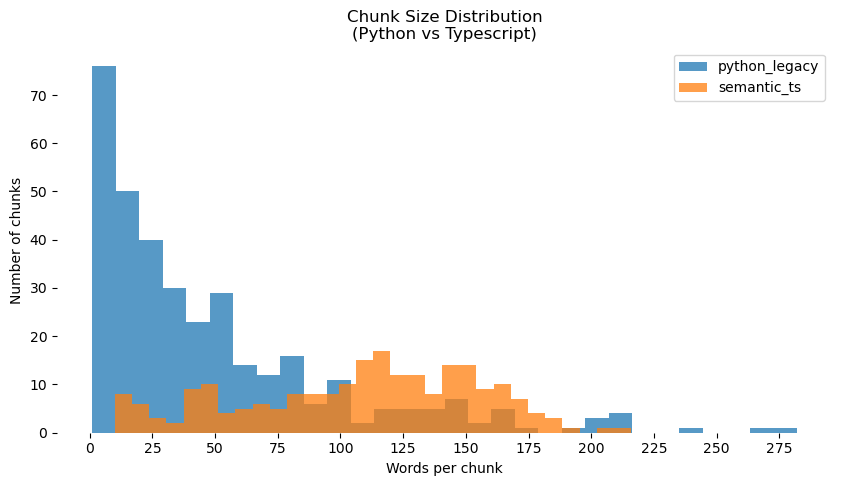

In [20]:
#Worc Count Histogram
plot_frame = pd.concat(frames.values(), ignore_index=True)
plt.figure(figsize=(10, 5))
for source_name, group in plot_frame.groupby("source_name"):
    plt.hist(group["wordCount"], bins=30, alpha=0.75, label=source_name)
plt.xlabel("Words per chunk")
plt.xticks(np.arange(0,300, 25))
plt.ylabel("Number of chunks")
plt.title("Chunk Size Distribution\n(Python vs Typescript)")
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.legend()
plt.show()


## Coverage Check

Compare normalized sentence and word coverage between `semantic_ts` and `python_legacy` so chunk-size differences do not hide missing text.


In [9]:
def normalize_text(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()


def split_sentence_like(text: str) -> list[str]:
    normalized = normalize_text(text)
    if not normalized:
        return []
    parts = re.split(r'(?<=[.!?])\s+', normalized)
    return [part.strip() for part in parts if part.strip()]


def tokenize_words(text: str) -> list[str]:
    return re.findall(r"[A-Za-z0-9']+", text.lower())


def collect_sentence_set(frame: pd.DataFrame) -> set[str]:
    sentences = set()
    for content in frame['content']:
        sentences.update(split_sentence_like(content))
    return sentences


def collect_word_set(frame: pd.DataFrame) -> set[str]:
    words = set()
    for content in frame['content']:
        words.update(tokenize_words(content))
    return words


if 'semantic_ts' not in frames or 'python_legacy' not in frames:
    raise FileNotFoundError('Need both semantic_ts and python_legacy loaded before running coverage comparison')

semantic_sentences = collect_sentence_set(frames['semantic_ts'])
python_sentences = collect_sentence_set(frames['python_legacy'])
semantic_words = collect_word_set(frames['semantic_ts'])
python_words = collect_word_set(frames['python_legacy'])

coverage_summary = pd.DataFrame([
    {
        'metric': 'sentences',
        'semantic_count': len(semantic_sentences),
        'python_count': len(python_sentences),
        'missing_from_semantic': len(python_sentences - semantic_sentences),
        'extra_in_semantic': len(semantic_sentences - python_sentences),
        'semantic_overlap_pct': round(100 * len(semantic_sentences & python_sentences) / max(len(python_sentences), 1), 2),
    },
    {
        'metric': 'words',
        'semantic_count': len(semantic_words),
        'python_count': len(python_words),
        'missing_from_semantic': len(python_words - semantic_words),
        'extra_in_semantic': len(semantic_words - python_words),
        'semantic_overlap_pct': round(100 * len(semantic_words & python_words) / max(len(python_words), 1), 2),
    },
])
coverage_summary

,metric,semantic_count,python_count,missing_from_semantic,extra_in_semantic,semantic_overlap_pct
0,sentences,1359,1005,258,612,74.33
1,words,3374,2922,6,458,99.79


In [10]:
missing_sentence_samples = pd.DataFrame({
    'missing_from_semantic': sorted(python_sentences - semantic_sentences)[:20],
})
extra_sentence_samples = pd.DataFrame({
    'extra_in_semantic': sorted(semantic_sentences - python_sentences)[:20],
})
missing_word_samples = pd.DataFrame({
    'missing_words_from_semantic': sorted(python_words - semantic_words)[:50],
})
extra_word_samples = pd.DataFrame({
    'extra_words_in_semantic': sorted(semantic_words - python_words)[:50],
})

display(coverage_summary)
display(missing_sentence_samples)
display(extra_sentence_samples)
display(missing_word_samples)
display(extra_word_samples)

,metric,semantic_count,python_count,missing_from_semantic,extra_in_semantic,semantic_overlap_pct
0,sentences,1359,1005,258,612,74.33
1,words,3374,2922,6,458,99.79


,missing_from_semantic
0,(NOTE: This prevents back flow of blood from t...
1,* * A casualty with TBI (maintain oxygen satur...
2,* * Administer 400 mg moxifloxacin from the CW...
3,* * Administer 400 mg moxifloxacin from the CWPP.
4,* * Allow a conscious casualty to assume any p...
5,* * An unconscious casualty.
6,"* * As the needle enters the pleural space, a ..."
7,* * Assume a C-spine injury until cleared.
8,* * Burping or temporarily removing the dressing.
9,"* * Casualty at altitude (over 5,000 feet abov..."


,extra_in_semantic
0,( NOTE: This prevents back flow of blood from ...
1,(Available in both the Combat Medic and Tactic...
2,(Available in the Combat Medic MES.)
3,(Available in the Tactical Combat Medical Care...
4,(Available in the Tactical Combat Medical Care...
5,(See Figure 6-2.)
6,* •• A casualty with TBI (maintain oxygen satu...
7,* •• Administer 400 mg moxifloxacin from the C...
8,* •• Allow a conscious casualty to assume any ...
9,* •• An unconscious casualty.


,missing_words_from_semantic
0,dha
1,improve
2,pursuing
3,resides
4,standardization
5,we


,extra_words_in_semantic
0,101
1,105
2,107
3,109
4,111
5,113
6,115
7,121
8,1341
9,1346


## Page Spot Check

Use this to inspect one page at a time without scrolling through the whole file.


In [11]:
PAGE_TO_INSPECT = 0
MAX_ROWS_PER_SOURCE = 12

page_frames = []
for source_name in ['python_legacy', 'semantic_ts', 'baseline_ts']:
    frame = frames.get(source_name)
    if frame is None:
        continue

    sample = frame.loc[frame['pageIndex'] == PAGE_TO_INSPECT, [
        'source_name', 'chunkIndex', 'wordCount', 'sentenceCountApprox', 'content'
    ]].head(MAX_ROWS_PER_SOURCE)
    page_frames.append(sample)

pd.concat(page_frames, ignore_index=True) if page_frames else pd.DataFrame()

,source_name,chunkIndex,wordCount,sentenceCountApprox,content


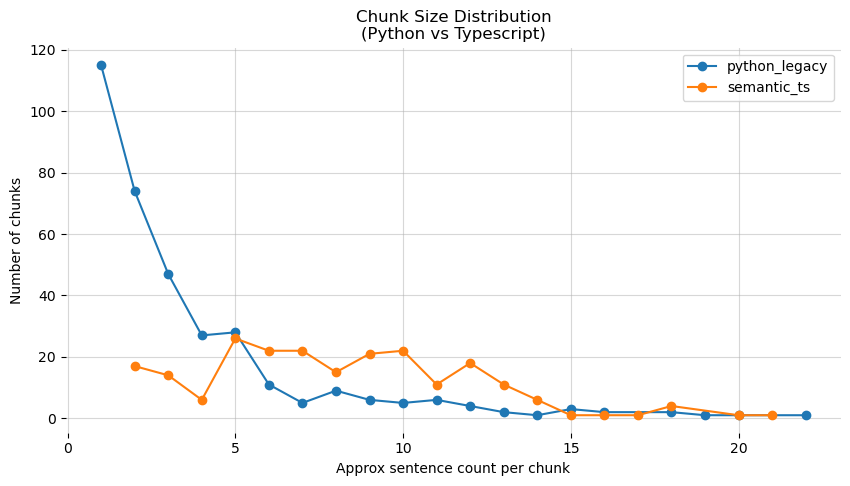

In [24]:
plot_frame = pd.concat(frames.values(), ignore_index=True)
plt.figure(figsize=(10, 5))
for source_name, group in plot_frame.groupby("source_name"):
    counts = group["sentenceCountApprox"].value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker="o", label=source_name)

plt.xlabel("Approx sentence count per chunk")
plt.ylabel("Number of chunks")
plt.title("Chunk Size Distribution\n(Python vs Typescript)")
plt.legend()
plt.grid(alpha=0.5)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()